In [97]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [98]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [99]:
df_train

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [100]:
df_test

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [101]:
df_train = df_train.drop('PassengerId',axis = 1)
df_test = df_test.drop('PassengerId',axis = 1)

In [102]:
df_train = df_train.drop('Name',axis = 1)
df_test = df_test.drop('Name',axis = 1)

In [103]:
df_train.isna().sum()

HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
dtype: int64

In [104]:
df_test.isna().sum()

HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
dtype: int64

In [105]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   object 
 1   CryoSleep     8476 non-null   object 
 2   Cabin         8494 non-null   object 
 3   Destination   8511 non-null   object 
 4   Age           8514 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8512 non-null   float64
 7   FoodCourt     8510 non-null   float64
 8   ShoppingMall  8485 non-null   float64
 9   Spa           8510 non-null   float64
 10  VRDeck        8505 non-null   float64
 11  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(5)
memory usage: 755.7+ KB


In [106]:
df_train[["Deck", "CabinNum", "Side"]] = df_train["Cabin"].str.split("/", expand=True)
df_test[["Deck", "CabinNum", "Side"]] = df_test["Cabin"].str.split("/", expand=True)

df_train = df_train.drop("Cabin", axis=1)
df_test = df_test.drop("Cabin", axis=1)


In [142]:
df_train

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side
0,1,0,2,39,0,0.0,0.0,0.0,0.0,0.0,False,B,0,P
1,0,0,2,24,0,109.0,9.0,25.0,549.0,44.0,True,F,0,S
2,1,0,2,58,1,43.0,3576.0,0.0,6715.0,49.0,False,A,0,S
3,1,0,2,33,0,0.0,1283.0,371.0,3329.0,193.0,False,A,0,S
4,0,0,2,16,0,303.0,70.0,151.0,565.0,2.0,True,F,1,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,1,0,0,41,1,0.0,6819.0,0.0,1643.0,74.0,False,A,98,P
8689,0,1,1,18,0,0.0,0.0,0.0,0.0,0.0,False,G,1499,S
8690,0,0,2,26,0,0.0,0.0,1872.0,1.0,0.0,True,G,1500,S
8691,1,0,0,32,0,0.0,1049.0,0.0,353.0,3235.0,False,E,608,S


In [145]:
df_test

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side
0,0,1,2,27,0,0.0,0.0,0.0,0.0,0.0,G,3,S
1,0,0,2,19,0,0.0,9.0,0.0,2823.0,0.0,F,4,S
2,1,1,0,31,0,0.0,0.0,0.0,0.0,0.0,C,0,S
3,1,0,2,38,0,0.0,6652.0,0.0,181.0,585.0,C,1,S
4,0,0,2,20,0,10.0,0.0,635.0,0.0,0.0,F,5,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,0,1,2,34,0,0.0,0.0,0.0,0.0,0.0,G,1496,S
4273,0,0,2,42,0,0.0,847.0,17.0,10.0,144.0,NaN,NaN,NaN
4274,2,1,0,27,0,0.0,0.0,0.0,0.0,0.0,D,296,P
4275,1,0,2,27,0,0.0,2680.0,0.0,0.0,523.0,D,297,P


In [155]:
df_train.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
CabinNum        0
Side            0
dtype: int64

In [156]:
df_test.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Deck            0
CabinNum        0
Side            0
dtype: int64

In [157]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   int64  
 1   CryoSleep     8693 non-null   int64  
 2   Destination   8693 non-null   int64  
 3   Age           8693 non-null   int64  
 4   VIP           8693 non-null   int64  
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   bool   
 11  Deck          8693 non-null   int64  
 12  CabinNum      8693 non-null   int64  
 13  Side          8693 non-null   int64  
dtypes: bool(1), float64(5), int64(8)
memory usage: 891.5 KB


In [111]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

In [112]:
mode_emb = df_train['HomePlanet'].mode()[0]
df_train['HomePlanet'] = df_train['HomePlanet'].fillna(mode_emb)
df_test['HomePlanet'] = df_test['HomePlanet'].fillna(mode_emb)

In [113]:
df_train['HomePlanet'] = label.fit_transform(df_train['HomePlanet'])
df_test['HomePlanet'] = label.fit_transform(df_test['HomePlanet'])

In [114]:
df_train['CryoSleep'] = pd.to_numeric(df_train['CryoSleep'],errors='coerce')
df_test['CryoSleep'] = pd.to_numeric(df_test['CryoSleep'],errors='coerce')
median_hs = df_train['CryoSleep'].median()
df_train['CryoSleep'] = df_train['CryoSleep'].fillna(median_hs)
df_test['CryoSleep'] = df_test['CryoSleep'].fillna(median_hs)

In [115]:
df_train['CryoSleep'] = label.fit_transform(df_train['CryoSleep'])
df_test['CryoSleep'] = label.fit_transform(df_test['CryoSleep'])

In [116]:
mode_emb = df_train['Destination'].mode()[0]
df_train['Destination'] = df_train['Destination'].fillna(mode_emb)
df_test['Destination'] = df_test['Destination'].fillna(mode_emb)

In [117]:
df_train['Destination'] = label.fit_transform(df_train['Destination'])
df_test['Destination'] = label.fit_transform(df_test['Destination'])

In [121]:
df_train['Age'] = pd.to_numeric(df_train['Age'],errors='coerce')
df_test['Age'] = pd.to_numeric(df_test['Age'],errors='coerce')
median_hs = df_train['Age'].median()
df_train['Age'] = df_train['Age'].fillna(median_hs)
df_test['Age'] = df_test['Age'].fillna(median_hs)

In [122]:
df_train['Age'] = label.fit_transform(df_train['Age'])
df_test['Age'] = label.fit_transform(df_test['Age'])

In [126]:
df_train['VIP'] = pd.to_numeric(df_train['VIP'],errors='coerce')
df_test['VIP'] = pd.to_numeric(df_test['VIP'],errors='coerce')
median_hs = df_train['VIP'].median()
df_train['VIP'] = df_train['VIP'].fillna(median_hs)
df_test['VIP'] = df_test['VIP'].fillna(median_hs)

In [127]:
df_train['VIP'] = label.fit_transform(df_train['VIP'])
df_test['VIP'] = label.fit_transform(df_test['VIP'])

In [128]:
df_train['RoomService'] = pd.to_numeric(df_train['RoomService'],errors='coerce')
df_test['RoomService'] = pd.to_numeric(df_test['RoomService'],errors='coerce')
median_hs = df_train['RoomService'].median()
df_train['RoomService'] = df_train['RoomService'].fillna(median_hs)
df_test['RoomService'] = df_test['RoomService'].fillna(median_hs)

In [133]:
df_train['FoodCourt'] = pd.to_numeric(df_train['FoodCourt'],errors='coerce')
df_test['FoodCourt'] = pd.to_numeric(df_test['FoodCourt'],errors='coerce')
median_hs = df_train['FoodCourt'].median()
df_train['FoodCourt'] = df_train['FoodCourt'].fillna(median_hs)
df_test['FoodCourt'] = df_test['FoodCourt'].fillna(median_hs)

In [134]:
df_train['ShoppingMall'] = pd.to_numeric(df_train['ShoppingMall'],errors='coerce')
df_test['ShoppingMall'] = pd.to_numeric(df_test['ShoppingMall'],errors='coerce')
median_hs = df_train['ShoppingMall'].median()
df_train['ShoppingMall'] = df_train['ShoppingMall'].fillna(median_hs)
df_test['ShoppingMall'] = df_test['ShoppingMall'].fillna(median_hs)

In [138]:
df_train['Spa'] = pd.to_numeric(df_train['Spa'],errors='coerce')
df_test['Spa'] = pd.to_numeric(df_test['Spa'],errors='coerce')
median_hs = df_train['Spa'].median()
df_train['Spa'] = df_train['Spa'].fillna(median_hs)
df_test['Spa'] = df_test['Spa'].fillna(median_hs)

In [141]:
df_train['VRDeck'] = pd.to_numeric(df_train['VRDeck'],errors='coerce')
df_test['VRDeck'] = pd.to_numeric(df_test['VRDeck'],errors='coerce')
median_hs = df_train['VRDeck'].median()
df_train['VRDeck'] = df_train['VRDeck'].fillna(median_hs)
df_test['VRDeck'] = df_test['VRDeck'].fillna(median_hs)

In [146]:
mode_emb = df_train['Deck'].mode()[0]
df_train['Deck'] = df_train['Deck'].fillna(mode_emb)
df_test['Deck'] = df_test['Deck'].fillna(mode_emb)

In [147]:
df_train['Deck'] = label.fit_transform(df_train['Deck'])
df_test['Deck'] = label.fit_transform(df_test['Deck'])

In [148]:
df_train['CabinNum'] = pd.to_numeric(df_train['CabinNum'],errors='coerce')
df_test['CabinNum'] = pd.to_numeric(df_test['CabinNum'],errors='coerce')
median_hs = df_train['CabinNum'].median()
df_train['CabinNum'] = df_train['CabinNum'].fillna(median_hs)
df_test['CabinNum'] = df_test['CabinNum'].fillna(median_hs)

In [149]:
df_train['CabinNum'] = label.fit_transform(df_train['CabinNum'])
df_test['CabinNum'] = label.fit_transform(df_test['CabinNum'])

In [153]:
mode_emb = df_train['Side'].mode()[0]
df_train['Side'] = df_train['Side'].fillna(mode_emb)
df_test['Side'] = df_test['Side'].fillna(mode_emb)

In [154]:
df_train['Side'] = label.fit_transform(df_train['Side'])
df_test['Side'] = label.fit_transform(df_test['Side'])

In [158]:
X_train = df_train.drop('Transported', axis=1)
y_train = df_train['Transported']
X_test = df_test.copy()

In [159]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [162]:
model = DecisionTreeClassifier()

In [163]:
params = {
    'criterion':["gini", "entropy", "log_loss"],
    'splitter':['best','random'],
    'max_depth':[4,5,6,8,10,12]
}

In [164]:
final_model = GridSearchCV(model,params,cv = 3,verbose = 2)

In [165]:
final_model.fit(X_train,y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=4, splitter=best; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=4, splitter=random; total time=   0.0s
[CV] END .........criterion=gini, max_depth=5, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=5, splitter=best; total time=   0.0s
[CV] END .........criterion=gini, max_depth=5, splitter=best; total time=   0.0s
[CV] END .......criterion=gini, max_depth=5, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=5, splitter=random; total time=   0.0s
[CV] END .......criterion=gini, max_depth=5, sp

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [4, 5, ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 :

In [166]:
final_tree = final_model.best_estimator_

In [167]:
final_model.best_params_

{'criterion': 'entropy', 'max_depth': 4, 'splitter': 'best'}

In [168]:
from sklearn.tree import plot_tree

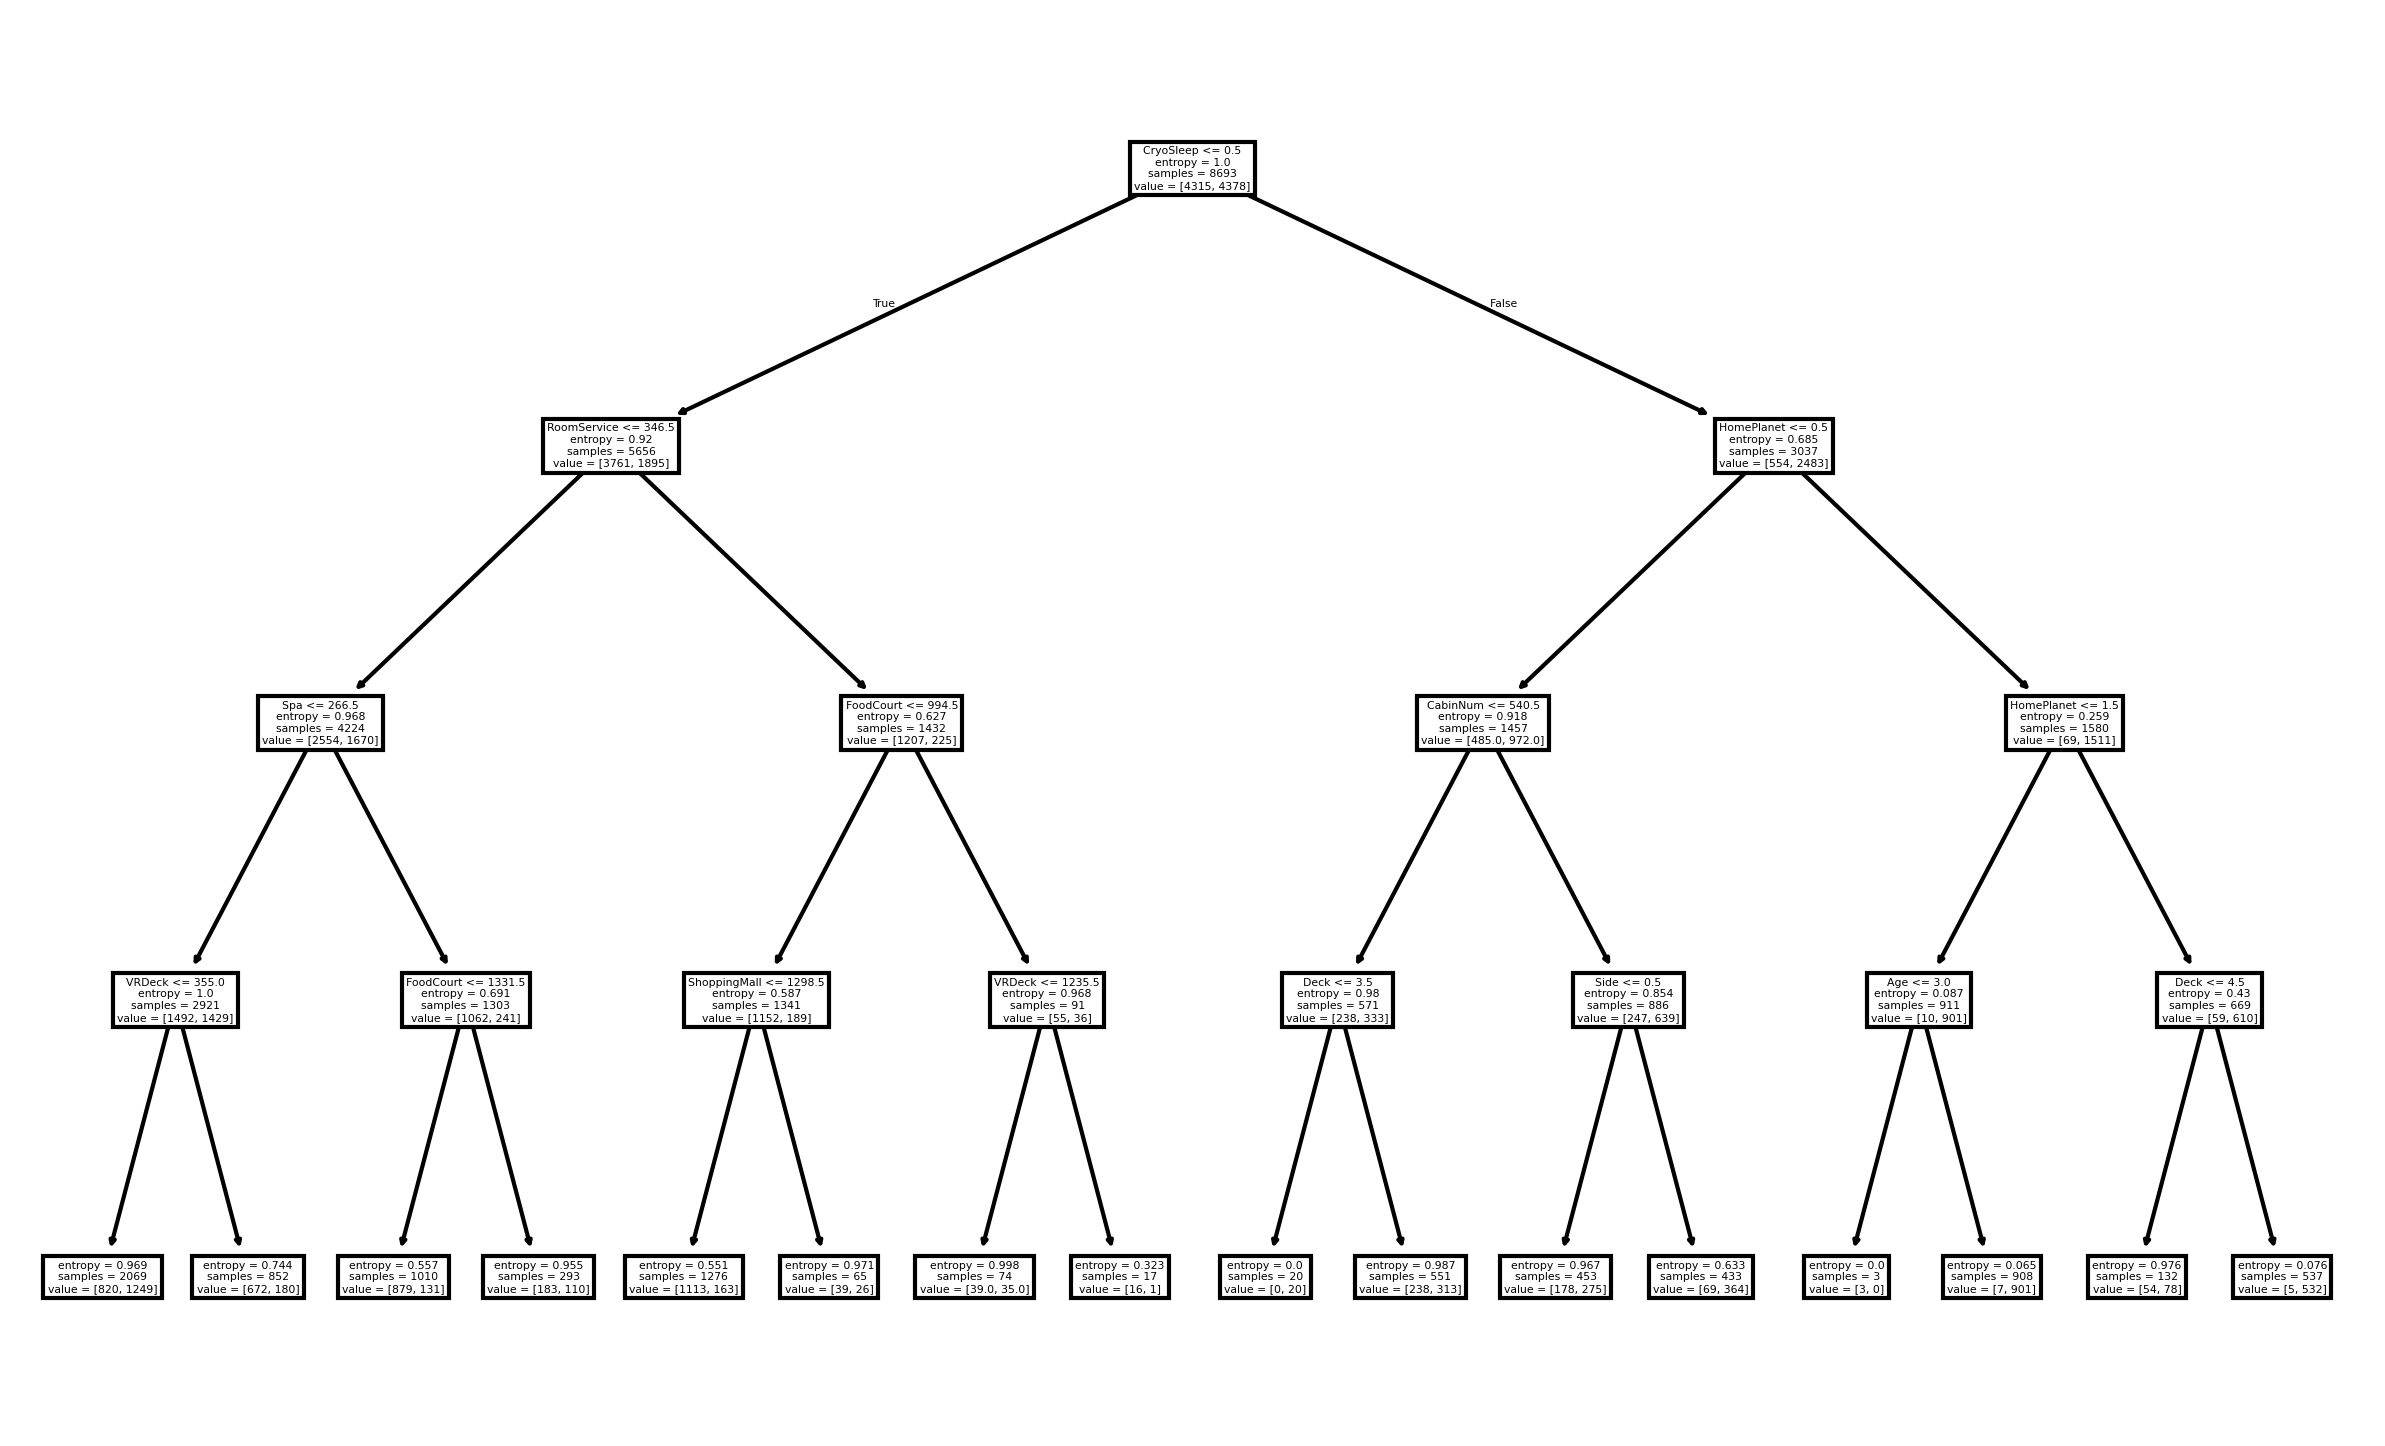

In [170]:
plt.figure(figsize=(10, 6), dpi=300)
plot_tree(final_tree, feature_names=X_train.columns)
plt.show()

In [171]:
y_pred = final_model.predict(X_test)

In [173]:
df_sub = pd.read_csv('sample_submission.csv')

In [174]:
df_sub['Transported'] = y_pred

In [175]:
df_sub.to_csv('sub.csv',index = False,index_label=False)

In [176]:
df_sub

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,False
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,False
